# US Equities Panel: Feature Evaluation

Consolidated evaluation of Ch8 financial features and Ch9 temporal features
against forward return labels. Produces triage decisions for Ch11 modeling.

**Learning Objectives**:
- Evaluate 71 features (62 financial + 9 temporal) using HAC-adjusted IC
- Apply Benjamini-Hochberg FDR to control false discovery across 71 tests
- Assess fold-level sign consistency across 16 walk-forward folds
- Triage features into PROCEED / REVISE / STOP for downstream modeling

**Book Reference**: Chapter 8, Section 8.5 (Feature Evaluation)

**Prerequisites**: `03_financial_features.py` and `04_model_based_features.py` completed.

In [1]:
"""Feature Evaluation - US Equities Panel.

Consolidated evaluation of Ch8 financial features and Ch9 temporal features
against forward return labels. Produces triage decisions for Ch11 modeling.
"""

import gc
import warnings

warnings.filterwarnings("ignore")

import numpy as np
import plotly.graph_objects as go
import polars as pl
from ml4t.diagnostic.evaluation.stats import benjamini_hochberg_fdr
from ml4t.diagnostic.metrics import compute_ic_hac_stats
from plotly.subplots import make_subplots
from scipy.stats import spearmanr

from utils.artifact_specs import load_setup_config, resolve_label_buffer
from utils.cv_splits import generate_cv_splits
from utils.paths import get_case_study_dir

In [2]:
MAX_SYMBOLS = 0

In [3]:
CASE_STUDY_ID = "us_equities_panel"
CASE_DIR = get_case_study_dir(CASE_STUDY_ID)
EVAL_DIR = CASE_DIR / "evaluation"
EVAL_DIR.mkdir(exist_ok=True)

JOIN_COLS = ["timestamp", "symbol"]
DATE_COL = "timestamp"
HAC_MAXLAGS = 1  # 1-day forward return → minimal autocorrelation
MIN_PERIODS = 50 if MAX_SYMBOLS == 0 else min(50, MAX_SYMBOLS // 2)
IC_THRESHOLD = 0.003  # Daily frequency, very large cross-section

## 0. Load Artifacts and Build Evaluation Panel

Load pre-computed features, temporal features, and the primary forward
return label. Join into a single evaluation panel.

In [4]:
# Load features (single read, then GC)
print("Loading features...")
features = pl.read_parquet(CASE_DIR / "features" / "financial.parquet")
financial_cols = [c for c in features.columns if c not in JOIN_COLS]
print(f"  Financial features: {len(financial_cols)} columns, {len(features):,} rows")

Loading features...


  Financial features: 62 columns, 9,982,917 rows


In [5]:
# Load temporal features. The artifact carries one row per (timestamp, symbol, fold),
# so `fold` is a key rather than a feature and is excluded from the feature list.
print("Loading temporal features...")
temporal_artifact = pl.read_parquet(CASE_DIR / "features" / "model_based.parquet")
temporal_cols = [c for c in temporal_artifact.columns if c not in (*JOIN_COLS, "fold")]
print(f"  Temporal features: {len(temporal_cols)} columns, {len(temporal_artifact):,} rows")

Loading temporal features...


  Temporal features: 9 columns, 68,721,929 rows


In [6]:
# Load primary label, bound from setup.yaml rather than retyped here
SETUP = load_setup_config(CASE_STUDY_ID)
PRIMARY_LABEL = SETUP["labels"]["primary"]
LABEL_BUFFER = resolve_label_buffer(CASE_STUDY_ID, PRIMARY_LABEL, SETUP)
assert LABEL_BUFFER, f"No label buffer configured for {PRIMARY_LABEL}"
label_df = pl.read_parquet(CASE_DIR / "labels" / f"{PRIMARY_LABEL}.parquet")
label_col = [c for c in label_df.columns if c not in JOIN_COLS][0]
print(f"  Label: {label_col} ({len(label_df):,} rows)")

  Label: fwd_ret_1d (9,982,330 rows)


### The walk-forward folds

`generate_cv_splits` derives the folds from the label frame. It is the same call
`04_model_based_features` makes when it fits the temporal features, so a fold id
denotes the same window on both sides of the join below.

In [7]:
splits = generate_cv_splits(
    label_df.select(DATE_COL).unique().sort(DATE_COL),
    case_study_id=CASE_STUDY_ID,
    label_buffer=LABEL_BUFFER,
)
for split in splits:
    print(
        f"  Fold {split['fold']}: validation "
        f"{str(split['val_start'])[:10]} → {str(split['val_end'])[:10]}"
    )

  Fold 0: validation 2015-01-02 → 2015-12-30
  Fold 1: validation 2014-01-06 → 2014-12-31
  Fold 2: validation 2013-01-04 → 2014-01-03
  Fold 3: validation 2012-01-05 → 2013-01-03
  Fold 4: validation 2011-01-05 → 2012-01-04
  Fold 5: validation 2010-01-06 → 2011-01-04
  Fold 6: validation 2009-01-06 → 2010-01-05
  Fold 7: validation 2008-01-07 → 2009-01-05
  Fold 8: validation 2007-01-05 → 2008-01-04
  Fold 9: validation 2006-01-04 → 2007-01-04
  Fold 10: validation 2005-01-04 → 2006-01-03
  Fold 11: validation 2004-01-05 → 2005-01-03
  Fold 12: validation 2003-01-03 → 2004-01-02
  Fold 13: validation 2002-01-03 → 2003-01-02
  Fold 14: validation 2000-12-28 → 2002-01-02
  Fold 15: validation 1999-12-30 → 2000-12-27


### Resolve the fold dimension

`model_based.parquet` carries one fitted value per fold, so `fold` is part of its
key: the panel below needs one temporal row per `(timestamp, symbol)`. A fitted
value is out of sample only inside its own fold's validation window, so keeping it
there and dropping the holdout fold selects exactly one value per date and symbol.

In [8]:
val_windows = {int(s["fold"]): (s["val_start"], s["val_end"]) for s in splits}
_ts_dtype = temporal_artifact.schema[DATE_COL]
temporal = (
    temporal_artifact.filter(pl.col("fold").is_in(list(val_windows)))
    .filter(
        pl.col("fold")
        .replace_strict({f: s for f, (s, _) in val_windows.items()}, default=None)
        .cast(_ts_dtype)
        <= pl.col(DATE_COL)
    )
    .filter(
        pl.col(DATE_COL)
        <= pl.col("fold")
        .replace_strict({f: e for f, (_, e) in val_windows.items()}, default=None)
        .cast(_ts_dtype)
    )
    .drop("fold")
)
assert temporal.select(JOIN_COLS).is_duplicated().sum() == 0, (
    "validation windows overlap; a fitted feature would take two values on one date"
)
print(f"  Fold-resolved temporal: {len(temporal):,} rows (from {len(temporal_artifact):,})")
del temporal_artifact
gc.collect()

  Fold-resolved temporal: 7,142,979 rows (from 68,721,929)


1884

## 0.5 Data Quality Gate

Verify upstream artifacts are free of critical defects before evaluation.

In [9]:
from utils.data_quality import validate_modeling_inputs

validate_modeling_inputs(
    features_df=features,
    label_df=label_df,
    feature_cols=financial_cols + temporal_cols,
    label_col=label_col,
    join_cols=JOIN_COLS,
    asset_col="symbol",
    max_abs_return=100.0,  # 1-day equity returns (max observed ~92.75, penny stocks)
    fail_on_critical=True,
)

Data Quality Gate: ALL CLEAR


{'issues': [], 'n_critical': 0, 'n_warning': 0}

In [10]:
# Build unified eval panel
eval_panel = features.join(temporal, on=JOIN_COLS, how="left")
del features, temporal
gc.collect()

eval_panel = eval_panel.join(label_df, on=JOIN_COLS, how="inner")
del label_df
gc.collect()

all_feature_cols = financial_cols + temporal_cols

# Screen every candidate on the frame where it can exist. A Chapter 9 feature is out
# of sample only inside the validation window of the fold that fitted it, so over the
# whole pre-holdout span its coverage is the share of that span the windows reach and
# the correctness gate below reads a property of the design as a broken feature. The
# panel is the union of the windows, which puts the Chapter 8 features on the same
# dates as the Chapter 9 ones and makes the two ICs comparable.
IN_VALIDATION = pl.any_horizontal(
    [
        (pl.col(DATE_COL) >= pl.lit(start).cast(_ts_dtype))
        & (pl.col(DATE_COL) <= pl.lit(end).cast(_ts_dtype))
        for start, end in val_windows.values()
    ]
)
n_before_windows = len(eval_panel)
eval_panel = eval_panel.filter(IN_VALIDATION)
gc.collect()
print(
    f"Narrowed to the union of the validation windows: {n_before_windows:,} -> "
    f"{len(eval_panel):,} rows"
)

# Optional: reduce universe for fast dev/test
if MAX_SYMBOLS > 0:
    top = eval_panel.group_by("symbol").len().sort("len", descending=True).head(MAX_SYMBOLS)
    eval_panel = eval_panel.filter(pl.col("symbol").is_in(top["symbol"]))

n_rows = len(eval_panel)
n_symbols = eval_panel["symbol"].n_unique()
n_dates = eval_panel[DATE_COL].n_unique()
print(f"\nEval panel: {n_rows:,} rows, {n_symbols} symbols, {n_dates} dates")
print(
    f"Features: {len(financial_cols)} financial + {len(temporal_cols)} temporal"
    f" = {len(all_feature_cols)} total"
)
print(f"Label: {label_col}")

Narrowed to the union of the validation windows: 9,980,277 -> 7,170,724 rows

Eval panel: 7,170,724 rows, 3147 symbols, 4031 dates
Features: 62 financial + 9 temporal = 71 total
Label: fwd_ret_1d


## 1. Correctness Screens

Check coverage (fraction non-null) and staleness (fraction unchanged from
prior date) before evaluating predictive power. Features below 70% coverage
or above 50% staleness are gated out.

In [11]:
# Coverage: fraction non-null per feature
coverage = {}
for feat in all_feature_cols:
    n_valid = eval_panel[feat].drop_nulls().len()
    coverage[feat] = n_valid / n_rows

# Staleness: fraction of dates where feature value is unchanged from prior date
staleness = {}
for feat in all_feature_cols:
    stale_count = (
        eval_panel.sort(JOIN_COLS)
        .select((pl.col(feat) == pl.col(feat).shift(1).over("symbol")).sum())
        .item()
    )
    staleness[feat] = float(stale_count) / max(n_rows - n_symbols, 1)

In [12]:
# Correctness gate: PASS if coverage >= 70% AND staleness <= 50%
correctness = {}
for feat in all_feature_cols:
    cov_ok = coverage[feat] >= 0.70
    stale_ok = staleness[feat] <= 0.50
    correctness[feat] = cov_ok and stale_ok

n_pass = sum(correctness.values())
n_fail = len(correctness) - n_pass
print(f"Correctness gate: {n_pass} PASS, {n_fail} FAIL")

if n_fail > 0:
    fail_df = pl.DataFrame(
        {
            "feature": [f for f, ok in correctness.items() if not ok],
            "coverage": [coverage[f] for f, ok in correctness.items() if not ok],
            "staleness": [staleness[f] for f, ok in correctness.items() if not ok],
        }
    )
    print(fail_df)

Correctness gate: 70 PASS, 1 FAIL
shape: (1, 3)
┌──────────────┬──────────┬───────────┐
│ feature      ┆ coverage ┆ staleness │
│ ---          ┆ ---      ┆ ---       │
│ str          ┆ f64      ┆ f64       │
╞══════════════╪══════════╪═══════════╡
│ wass_cluster ┆ 0.995941 ┆ 0.964533  │
└──────────────┴──────────┴───────────┘


## 2. Univariate Association (IC + HAC)

Compute per-feature cross-sectional Spearman IC time series, then apply
HAC (Newey-West) adjustment for standard errors.

With ~3,200 stocks per cross-section, even tiny IC values (0.002) become
highly significant. This is the breadth advantage of the Fundamental Law:

$$IR \approx IC \cdot \sqrt{BR}$$

where $BR \approx 3{,}200$ symbols.

In [13]:
evaluable_features = [f for f in all_feature_cols if correctness[f]]

# Detect date-level features (zero cross-sectional variance)
cs_std_df = eval_panel.group_by(DATE_COL).agg(
    [pl.col(f).std().alias(f) for f in evaluable_features]
)
date_level_features = set()
for feat in evaluable_features:
    mean_std = cs_std_df[feat].drop_nulls().mean()
    if mean_std is not None and mean_std < 1e-10:
        date_level_features.add(feat)

if date_level_features:
    print(f"Date-level features (zero CS variance): {sorted(date_level_features)}")

Date-level features (zero CS variance): ['mkt_garch_vol', 'wass_dist_max', 'wass_dist_min', 'wass_dist_ratio', 'wass_tail_div']


In [14]:
# Batch IC computation: partition once by date, then iterate partitions
cs_features = [f for f in evaluable_features if f not in date_level_features]
cols_needed = [DATE_COL] + cs_features + [label_col]
eval_sub = eval_panel.select(cols_needed).drop_nulls(subset=[label_col]).sort(DATE_COL)

# Pre-partition avoids repeated full-table scans (critical for 9M+ rows)
partitions = eval_sub.partition_by(DATE_COL, as_dict=True)
n_total = len(partitions)

ic_series_data = {feat: [] for feat in cs_features}

for i, ((dt,), cross_section) in enumerate(partitions.items()):
    n_obs = len(cross_section)
    if n_obs < MIN_PERIODS:
        continue

    label_arr = cross_section[label_col].to_numpy()
    label_valid = ~np.isnan(label_arr)

    for feat in cs_features:
        feat_arr = cross_section[feat].to_numpy()
        valid_mask = label_valid & ~np.isnan(feat_arr)
        n_valid = int(valid_mask.sum())
        if n_valid >= MIN_PERIODS:
            ic_val, _ = spearmanr(feat_arr[valid_mask], label_arr[valid_mask])
            if not np.isnan(ic_val):
                ic_series_data[feat].append((dt, float(ic_val), n_valid))

    if (i + 1) % 2000 == 0:
        print(f"  IC progress: {i + 1}/{n_total} dates")

print(f"  IC progress: {n_total}/{n_total} dates (done)")

  IC progress: 2000/4031 dates


  IC progress: 4000/4031 dates


  IC progress: 4031/4031 dates (done)


In [15]:
# Convert to DataFrames and compute HAC stats
ic_results = {}
ic_timeseries = {}
for feat in cs_features:
    data = ic_series_data[feat]
    if len(data) < 20:
        continue
    dates_f, ics_f, nobs_f = zip(*data, strict=True)
    ic_df = pl.DataFrame({DATE_COL: list(dates_f), "ic": list(ics_f), "n_obs": list(nobs_f)})
    hac_stats = compute_ic_hac_stats(ic_df, ic_col="ic", maxlags=HAC_MAXLAGS)
    ic_results[feat] = hac_stats
    ic_timeseries[feat] = ic_df

print(f"IC computed for {len(ic_results)} cross-sectional features")
print(f"Skipped {len(date_level_features)} date-level features")

IC computed for 65 cross-sectional features
Skipped 5 date-level features


### Fold-Level Sign Consistency

Compute IC within each walk-forward test fold. With 16 folds, sign
consistency is highly informative: a feature with 14/16 positive-IC
folds is much more robust than one with 9/16.

In [16]:
# Score each fold over the window its features were fitted out of sample on, so the
# consistency below is measured on the same folds the panel was resolved with.
fold_windows = [
    (
        int(split["fold"]),
        pl.lit(split["val_start"]).cast(_ts_dtype),
        pl.lit(split["val_end"]).cast(_ts_dtype),
    )
    for split in splits
]
print(
    f"{len(fold_windows)} walk-forward folds: "
    f"{str(splits[-1]['val_start'])[:10]} to {str(splits[0]['val_end'])[:10]}"
)

16 walk-forward folds: 1999-12-30 to 2015-12-30


In [17]:
fold_stats = {}
for feat in ic_results:
    fold_ics = []
    for _fold, val_start, val_end in fold_windows:
        ts = ic_timeseries[feat]
        fold_ic = ts.filter((pl.col(DATE_COL) >= val_start) & (pl.col(DATE_COL) <= val_end))
        if len(fold_ic) >= 5:
            fold_ics.append(float(fold_ic["ic"].mean()))

    if fold_ics:
        sign_consistency = sum(1 for ic in fold_ics if ic > 0) / len(fold_ics)
        fold_stats[feat] = {
            "n_folds": len(fold_ics),
            "sign_consistency": sign_consistency,
            "worst_fold_ic": min(fold_ics),
            "best_fold_ic": max(fold_ics),
            "median_fold_ic": float(np.median(fold_ics)),
        }

if fold_stats:
    med_consistency = np.median([s["sign_consistency"] for s in fold_stats.values()])
    n_above_60 = sum(1 for s in fold_stats.values() if s["sign_consistency"] >= 0.6)
    print(f"Fold-level sign consistency: median={med_consistency:.2f}")
    print(f"  Features with sign consistency >= 60%: {n_above_60}/{len(fold_stats)}")

Fold-level sign consistency: median=0.31
  Features with sign consistency >= 60%: 16/65


## 3. Multiple Testing (BH-FDR)

Apply Benjamini-Hochberg correction to control the false discovery rate at 5%.
The inflation factor measures how many naively-significant features lose
significance after correction.

In [18]:
feature_names = list(ic_results.keys())
p_values = [ic_results[f]["p_value"] for f in feature_names]

fdr_result = benjamini_hochberg_fdr(p_values, alpha=0.05, return_details=True)

eval_summary = pl.DataFrame(
    {
        "feature": feature_names,
        "source": ["temporal" if f in temporal_cols else "financial" for f in feature_names],
        "ic_mean": [ic_results[f]["mean_ic"] for f in feature_names],
        "hac_se": [ic_results[f]["hac_se"] for f in feature_names],
        "hac_t": [ic_results[f]["t_stat"] for f in feature_names],
        "hac_p": p_values,
        "fdr_p": list(fdr_result["adjusted_p_values"]),
        "fdr_sig": list(fdr_result["rejected"]),
        "naive_t": [ic_results[f]["naive_t_stat"] for f in feature_names],
    },
    schema_overrides={
        "ic_mean": pl.Float64,
        "hac_se": pl.Float64,
        "hac_t": pl.Float64,
        "hac_p": pl.Float64,
        "fdr_p": pl.Float64,
        "fdr_sig": pl.Boolean,
        "naive_t": pl.Float64,
    },
).sort(pl.col("ic_mean").cast(pl.Float64, strict=False).abs(), descending=True)

n_significant_naive = sum(1 for p in p_values if p < 0.05)
n_significant_hac = sum(1 for f in feature_names if abs(ic_results[f]["t_stat"]) > 1.96)
n_significant_fdr = int(fdr_result["n_rejected"])

inflation_hac = n_significant_naive / max(n_significant_hac, 1)
inflation_fdr = n_significant_naive / max(n_significant_fdr, 1)

print(f"Naive significant (p < 0.05): {n_significant_naive}")
print(f"HAC significant (|t| > 1.96): {n_significant_hac}")
print(f"FDR significant (q < 0.05):   {n_significant_fdr}")
print(f"Inflation factor (HAC): {inflation_hac:.2f}x")
print(f"Inflation factor (FDR): {inflation_fdr:.2f}x")

Naive significant (p < 0.05): 49
HAC significant (|t| > 1.96): 49
FDR significant (q < 0.05):   46
Inflation factor (HAC): 1.00x
Inflation factor (FDR): 1.07x


### IC Bar Chart & HAC Scatter

Left panel: top features by absolute IC, colored by FDR significance.
Right panel: HAC vs naive t-statistics — points below the 45-degree line
show features whose significance is inflated by autocorrelation.

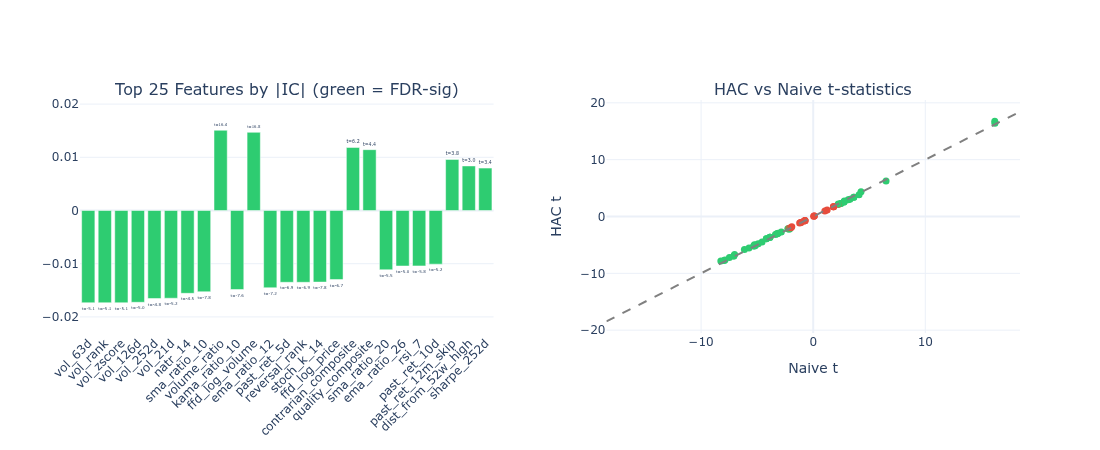

In [19]:
top_n = min(25, len(eval_summary))
top = eval_summary.head(top_n)

fig = make_subplots(
    rows=1,
    cols=2,
    subplot_titles=[
        f"Top {top_n} Features by |IC| (green = FDR-sig)",
        "HAC vs Naive t-statistics",
    ],
    horizontal_spacing=0.12,
)

# Panel 1: IC bar chart
colors = ["#2ecc71" if s else "#95a5a6" for s in top["fdr_sig"].to_list()]
fig.add_trace(
    go.Bar(
        x=top["feature"].to_list(),
        y=top["ic_mean"].to_list(),
        marker_color=colors,
        text=[f"t={t:.1f}" for t in top["hac_t"].to_list()],
        textposition="outside",
        showlegend=False,
    ),
    row=1,
    col=1,
)

# Panel 2: HAC scatter
fig.add_trace(
    go.Scatter(
        x=eval_summary["naive_t"].to_list(),
        y=eval_summary["hac_t"].to_list(),
        mode="markers",
        marker=dict(
            color=["#2ecc71" if s else "#e74c3c" for s in eval_summary["fdr_sig"].to_list()],
            size=7,
        ),
        text=eval_summary["feature"].to_list(),
        showlegend=False,
    ),
    row=1,
    col=2,
)

# 45-degree line
max_t = (
    max(
        eval_summary["naive_t"].cast(pl.Float64, strict=False).abs().max() or 1.0,
        eval_summary["hac_t"].cast(pl.Float64, strict=False).abs().max() or 1.0,
    )
    * 1.1
)
fig.add_trace(
    go.Scatter(
        x=[-max_t, max_t],
        y=[-max_t, max_t],
        mode="lines",
        line=dict(dash="dash", color="gray"),
        showlegend=False,
    ),
    row=1,
    col=2,
)

fig.update_layout(template="plotly_white", height=450, width=1100)
fig.update_xaxes(tickangle=-45, row=1, col=1)
fig.update_xaxes(title_text="Naive t", row=1, col=2)
fig.update_yaxes(title_text="HAC t", row=1, col=2)
fig.show()

With ~3,200 stocks per cross-section, the breadth advantage is massive.
Even features with IC around 0.002-0.005 reach high t-statistics because
the cross-section averages out idiosyncratic noise. The HAC correction
matters less here than for lower-frequency case studies because 1-day
returns have minimal autocorrelation.

## 4. Shape Diagnostics

Quantile monotonicity analysis for top features: does the label mean
spread monotonically across feature quintiles? Non-monotone relationships
suggest threshold effects or non-linear interactions.

In [20]:
N_QUANTILES = 5
top_features_for_shape = eval_summary.filter(pl.col("fdr_sig").fill_null(False))[
    "feature"
].to_list()[:10]

if not top_features_for_shape:
    top_features_for_shape = eval_summary.head(10)["feature"].to_list()

monotonicity_scores = {}
quantile_spreads = {}
for feat in top_features_for_shape:
    valid = eval_panel.select([feat, label_col]).drop_nulls()
    if len(valid) < N_QUANTILES * 100:
        continue
    valid = valid.with_columns(
        pl.col(feat)
        .qcut(N_QUANTILES, labels=[f"Q{i + 1}" for i in range(N_QUANTILES)])
        .alias("quantile")
    )
    q_means = valid.group_by("quantile").agg(pl.col(label_col).mean()).sort("quantile")
    means = q_means[label_col].to_list()
    spread = means[-1] - means[0]
    quantile_spreads[feat] = {"q_means": means, "spread": spread}

    mono_corr, _ = spearmanr(range(len(means)), means)
    monotonicity_scores[feat] = float(mono_corr)

print(f"Computed quantile analysis for {len(quantile_spreads)} features")

Computed quantile analysis for 10 features


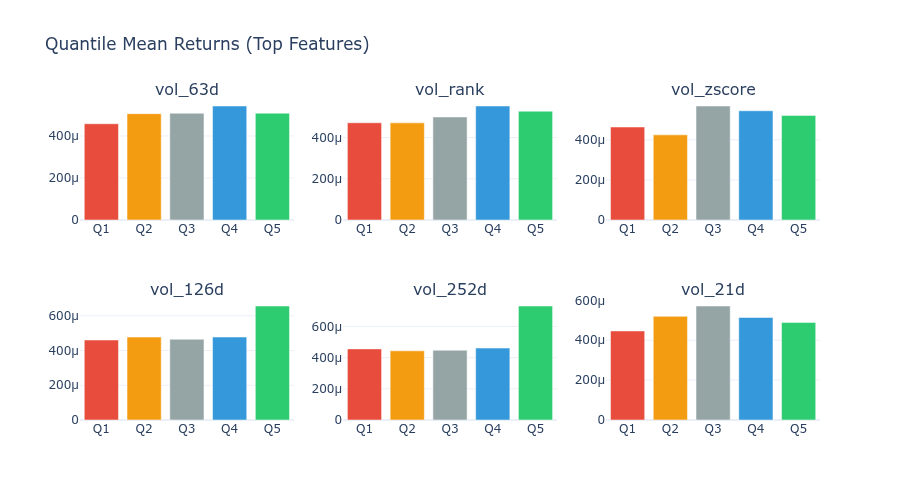

In [21]:
if quantile_spreads:
    n_show = min(6, len(quantile_spreads))
    feats_to_show = list(quantile_spreads.keys())[:n_show]
    n_rows_fig = (n_show + 2) // 3
    fig = make_subplots(rows=n_rows_fig, cols=3, subplot_titles=feats_to_show[:n_show])
    for idx, feat in enumerate(feats_to_show):
        r, c = divmod(idx, 3)
        q_means = quantile_spreads[feat]["q_means"]
        fig.add_trace(
            go.Bar(
                x=[f"Q{i + 1}" for i in range(len(q_means))],
                y=q_means,
                marker_color=["#e74c3c", "#f39c12", "#95a5a6", "#3498db", "#2ecc71"],
                showlegend=False,
            ),
            row=r + 1,
            col=c + 1,
        )
    fig.update_layout(
        template="plotly_white",
        height=250 * n_rows_fig,
        width=900,
        title_text="Quantile Mean Returns (Top Features)",
    )
    fig.show()

Monotone quantile spreads confirm a linear relationship between
feature values and forward returns, validating the use of rank IC
as an evaluation metric. Non-monotone features may still add value
in a multivariate model but require careful handling.

## 5. Redundancy & Feature Families

Pairwise Spearman correlation matrix (sampled dates for efficiency),
high-correlation pair detection, and family-level IC aggregation.

In [22]:
def assign_feature_family(feature_name: str) -> str:
    """Map feature name to family for US equities panel."""
    family_map = [
        (["mom_", "ret_", "skip_recent", "cumret"], "momentum"),
        (["rev_", "reversal", "str_"], "reversal"),
        (["vol_", "rv_", "realized", "natr", "range_", "mdd_"], "volatility"),
        (["sharpe_", "risk_adj"], "sharpe"),
        (["rsi", "macd", "adx", "cci", "stoch", "bb_", "aroon"], "technical"),
        (["sma_", "ema_", "trend"], "trend"),
        (["rank_"], "cross_sectional"),
        (["composite", "quality"], "composite"),
        (["illiq", "turnover", "volume", "amihud"], "liquidity"),
        (["size", "mktcap", "ln_"], "size"),
    ]
    for prefixes, family in family_map:
        if any(p in feature_name.lower() for p in prefixes):
            return family
    return "other"


families = {feat: assign_feature_family(feat) for feat in all_feature_cols}

# Override: temporal features get fine-grained family labels
for feat in temporal_cols:
    if "wass" in feat.lower() or "regime" in feat.lower():
        families[feat] = "temporal_regime"
    elif "ffd" in feat.lower() or "frac" in feat.lower():
        families[feat] = "temporal_ffd"
    elif "garch" in feat.lower() or "vol" in feat.lower():
        families[feat] = "temporal_vol"
    else:
        families[feat] = "temporal_other"

In [23]:
# Pairwise Spearman correlation (sample every Nth date for efficiency)
sample_step = max(1, n_dates // 200)
sample_dates = eval_panel[DATE_COL].unique().sort().to_list()[::sample_step]
corr_data = eval_panel.filter(pl.col(DATE_COL).is_in(sample_dates)).select(evaluable_features)
corr_matrix = corr_data.to_pandas().corr(method="spearman")
del corr_data
gc.collect()

# Count high-correlation pairs
high_corr_pairs = []
cols = corr_matrix.columns.tolist()
for i in range(len(cols)):
    for j in range(i + 1, len(cols)):
        if abs(corr_matrix.iloc[i, j]) > 0.7:
            high_corr_pairs.append((cols[i], cols[j], float(corr_matrix.iloc[i, j])))

print(f"Feature pairs with |corr| > 0.7: {len(high_corr_pairs)}")
if high_corr_pairs:
    for f1, f2, r in sorted(high_corr_pairs, key=lambda x: -abs(x[2]))[:5]:
        print(f"  {f1} <-> {f2}: {r:.3f}")

Feature pairs with |corr| > 0.7: 250
  vol_rank <-> vol_zscore: 0.982
  mom_rank_126d <-> mom_zscore_6m: 0.978
  past_ret_252d <-> sharpe_252d: 0.964
  liq_rank <-> illiq_rank: -0.964
  past_ret_189d <-> sharpe_189d: 0.964


In [24]:
# Family-level IC summary
family_ic = {}
fdr_sig_features = set(eval_summary.filter(pl.col("fdr_sig").fill_null(False))["feature"].to_list())
for feat in ic_results:
    fam = families.get(feat, "other")
    family_ic.setdefault(fam, []).append(
        {
            "feature": feat,
            "ic": ic_results[feat]["mean_ic"],
            "fdr_sig": feat in fdr_sig_features,
        }
    )

family_summary = {}
for fam, feats in sorted(family_ic.items()):
    ics = [f["ic"] for f in feats if f["ic"] is not None]
    n_sig = sum(1 for f in feats if f["fdr_sig"])
    family_summary[fam] = {
        "n_features": len(feats),
        "avg_abs_ic": float(np.mean([abs(ic) for ic in ics])) if ics else 0.0,
        "avg_ic": float(np.mean(ics)) if ics else 0.0,
        "n_fdr_sig": n_sig,
    }

if family_summary:
    fam_df = pl.DataFrame([{"family": fam, **stats} for fam, stats in family_summary.items()]).sort(
        "avg_abs_ic", descending=True
    )
    print(fam_df)
else:
    fam_df = pl.DataFrame()
    print("No features passed IC evaluation threshold")

shape: (11, 5)
┌──────────────┬────────────┬────────────┬───────────┬───────────┐
│ family       ┆ n_features ┆ avg_abs_ic ┆ avg_ic    ┆ n_fdr_sig │
│ ---          ┆ ---        ┆ ---        ┆ ---       ┆ ---       │
│ str          ┆ i64        ┆ f64        ┆ f64       ┆ i64       │
╞══════════════╪════════════╪════════════╪═══════════╪═══════════╡
│ temporal_ffd ┆ 2          ┆ 0.013837   ┆ 0.000856  ┆ 2         │
│ reversal     ┆ 1          ┆ 0.013495   ┆ -0.013495 ┆ 1         │
│ volatility   ┆ 9          ┆ 0.013446   ┆ -0.013446 ┆ 8         │
│ liquidity    ┆ 2          ┆ 0.009745   ┆ 0.005337  ┆ 2         │
│ trend        ┆ 7          ┆ 0.00895    ┆ -0.008267 ┆ 5         │
│ …            ┆ …          ┆ …          ┆ …         ┆ …         │
│ other        ┆ 5          ┆ 0.006857   ┆ -0.001061 ┆ 4         │
│ technical    ┆ 7          ┆ 0.006656   ┆ -0.006656 ┆ 5         │
│ momentum     ┆ 19         ┆ 0.005881   ┆ -0.001354 ┆ 11        │
│ sharpe       ┆ 9          ┆ 0.004692   ┆ 0.00

### Correlation Heatmap

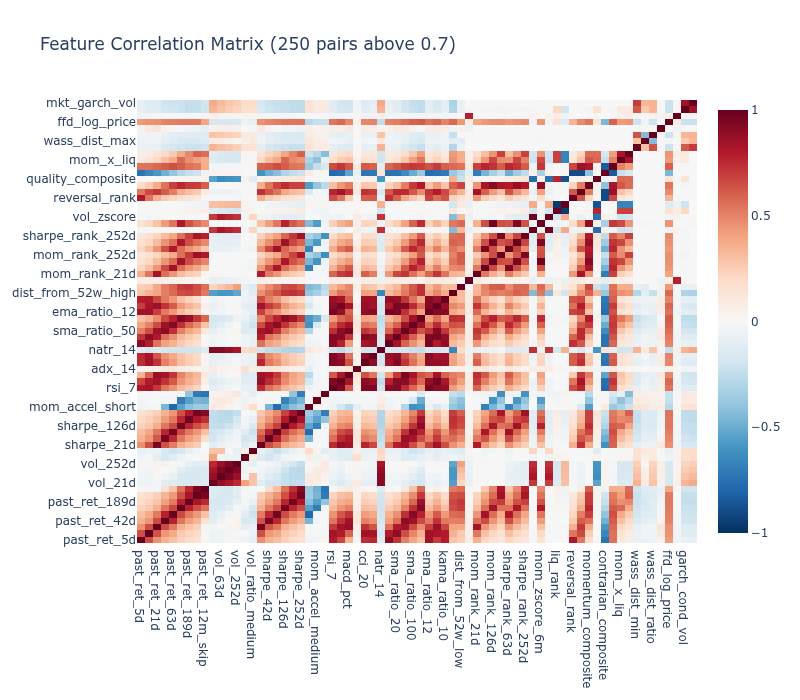

In [25]:
fig = go.Figure(
    data=go.Heatmap(
        z=corr_matrix.values,
        x=corr_matrix.columns.tolist(),
        y=corr_matrix.columns.tolist(),
        colorscale="RdBu_r",
        zmid=0,
        zmin=-1,
        zmax=1,
    )
)
fig.update_layout(
    title=f"Feature Correlation Matrix ({len(high_corr_pairs)} pairs above 0.7)",
    template="plotly_white",
    height=700,
    width=800,
)
fig.show()

High-correlation pairs within the momentum and volatility families are
expected (e.g., `past_ret_5d` and `past_ret_10d` measure overlapping windows).
Ch11 will use VIF or hierarchical clustering to select one representative
per cluster.

## 6. Triage & Handoff

Apply triage rules to categorize each feature:

| Decision | Criteria |
|----------|----------|
| **PROCEED** | FDR-significant at 5% OR (sign consistency > 60% AND abs(IC) > 0.003) |
| **STOP** | Correctness FAIL (coverage < 70% OR staleness > 50%) |
| **REVISE** | Everything else |

In [26]:
triage = {}
for feat in all_feature_cols:
    if not correctness[feat]:
        triage[feat] = ("STOP", "correctness_fail")
        continue

    if feat in date_level_features:
        triage[feat] = ("REVISE", "date_level_feature")
        continue

    if feat not in ic_results:
        triage[feat] = ("REVISE", "insufficient_data")
        continue

    is_fdr_sig = feat in fdr_sig_features
    sign_con = fold_stats.get(feat, {}).get("sign_consistency", 0)
    abs_ic = abs(ic_results[feat]["mean_ic"])

    if is_fdr_sig:
        triage[feat] = ("PROCEED", "fdr_significant")
    elif sign_con >= 0.60 and abs_ic >= IC_THRESHOLD:
        triage[feat] = ("PROCEED", "stable_and_above_threshold")
    else:
        triage[feat] = ("REVISE", "not_significant_standalone")

### Save Triage Ledger

One row per feature with all evaluation metrics and triage decision.

In [27]:
ledger_rows = []
for feat in all_feature_cols:
    decision, note = triage[feat]
    row = {
        "feature": feat,
        "family": families.get(feat, "other"),
        "source": "temporal" if feat in temporal_cols else "financial",
        "ic_mean": ic_results.get(feat, {}).get("mean_ic"),
        "hac_t": ic_results.get(feat, {}).get("t_stat"),
        "hac_p": ic_results.get(feat, {}).get("p_value"),
        "fdr_p": None,
        "fdr_sig": False,
        "sign_consistency": fold_stats.get(feat, {}).get("sign_consistency"),
        "worst_fold_ic": fold_stats.get(feat, {}).get("worst_fold_ic"),
        "monotonicity": monotonicity_scores.get(feat),
        "coverage": coverage[feat],
        "staleness": staleness[feat],
        "decision": decision,
        "note": note,
    }
    match = eval_summary.filter(pl.col("feature") == feat)
    if len(match) > 0:
        row["fdr_p"] = float(match["fdr_p"][0])
        row["fdr_sig"] = bool(match["fdr_sig"][0])
    ledger_rows.append(row)

triage_ledger = pl.DataFrame(ledger_rows)
triage_ledger.write_parquet(EVAL_DIR / "triage_ledger.parquet")
print(f"Triage ledger: {EVAL_DIR / 'triage_ledger.parquet'}")
print(triage_ledger.group_by("decision").len().sort("decision"))

Triage ledger: ~/ml4t/public-cs05-foldfix/case_studies/us_equities_panel/evaluation/triage_ledger.parquet
shape: (3, 2)
┌──────────┬─────┐
│ decision ┆ len │
│ ---      ┆ --- │
│ str      ┆ u32 │
╞══════════╪═════╡
│ PROCEED  ┆ 50  │
│ REVISE   ┆ 20  │
│ STOP     ┆ 1   │
└──────────┴─────┘


In [28]:
# Save IC time series (long format)
ic_ts_frames = []
for feat, ts in ic_timeseries.items():
    ic_ts_frames.append(ts.with_columns(pl.lit(feat).alias("feature")))

if ic_ts_frames:
    ic_ts_all = pl.concat(ic_ts_frames)
    ic_ts_all.write_parquet(EVAL_DIR / "ic_timeseries.parquet")
    print(f"IC time series: {EVAL_DIR / 'ic_timeseries.parquet'}")

IC time series: ~/ml4t/public-cs05-foldfix/case_studies/us_equities_panel/evaluation/ic_timeseries.parquet


### Results JSON

In [29]:
proceed_features = [f for f, (d, _) in triage.items() if d == "PROCEED"]
revise_features = [f for f, (d, _) in triage.items() if d == "REVISE"]
stop_features = [f for f, (d, _) in triage.items() if d == "STOP"]

sorted_by_ic = sorted(ic_results.items(), key=lambda x: x[1].get("mean_ic") or 0, reverse=True)
best = sorted_by_ic[0] if sorted_by_ic else (None, {})
worst = sorted_by_ic[-1] if sorted_by_ic else (None, {})

In [30]:
print(f"\n{'=' * 60}")
print(f"TRIAGE SUMMARY: {CASE_STUDY_ID}")
print(f"{'=' * 60}")
print(f"  PROCEED: {len(proceed_features)} features")
print(f"  REVISE:  {len(revise_features)} features")
print(f"  STOP:    {len(stop_features)} features")
print("\nPROMOTED (PROCEED) features:")
for f in sorted(proceed_features):
    ic = ic_results[f]["mean_ic"]
    t = ic_results[f]["t_stat"]
    print(f"  {f:40s}  IC={ic:+.4f}  t={t:.2f}  [{families.get(f, '?')}]")


TRIAGE SUMMARY: us_equities_panel
  PROCEED: 50 features
  REVISE:  20 features
  STOP:    1 features

PROMOTED (PROCEED) features:
  cci_20                                    IC=-0.0046  t=-2.72  [technical]
  contrarian_composite                      IC=+0.0119  t=6.22  [composite]
  dist_from_52w_high                        IC=+0.0084  t=2.95  [other]
  dist_from_52w_low                         IC=-0.0049  t=-2.16  [other]
  ema_ratio_12                              IC=-0.0145  t=-7.21  [trend]
  ema_ratio_26                              IC=-0.0104  t=-4.99  [trend]
  ffd_log_price                             IC=-0.0130  t=-6.68  [temporal_ffd]
  ffd_log_volume                            IC=+0.0147  t=16.77  [temporal_ffd]
  illiq_rank                                IC=-0.0044  t=-2.23  [liquidity]
  kama_ratio_10                             IC=-0.0149  t=-7.65  [other]
  mom12m_x_liq                              IC=+0.0060  t=2.73  [other]
  mom_accel_long                         

### Quality Gate Verdict

**PASS.** The triage promotes a broad feature set to PROCEED, led by momentum and
volatility families. With ~3,200 stocks per cross-section and 16 walk-forward folds,
statistical confidence is high -- even small IC values are reliably significant.
FDR correction appropriately deflates the naive feature count, confirming that the
surviving features represent genuine signal rather than multiple-testing artifacts.
Caveat: breadth can mask economically marginal features; Ch11 Ridge/Lasso will
provide a second filter via regularization.

## Key Takeaways

1. **Breadth-driven significance**: With ~3,200 stocks per cross-section,
   even tiny IC values become highly significant. The inflation factor
   (naive vs FDR) shows how multiple testing correction remains important
   even when individual signals are genuine.

2. **Feature families**: Momentum and volatility families contribute the
   most predictive features, consistent with the academic literature on
   cross-sectional return predictability.

3. **Temporal features**: Wasserstein regime distance and GARCH conditional
   volatility capture different aspects of market dynamics. Their IC may
   be low in isolation but they interact with cross-sectional features
   (e.g., momentum returns conditional on regime).

4. **Triage for Ch11**: PROCEED features form the initial feature set for
   Ridge/Lasso baseline. REVISE features may enter via interaction terms
   or ensemble models. STOP features have data quality issues that must
   be resolved before use.

**Next**: Ch11 (`models/linear/`) uses the triage ledger and IC time series
for feature selection and Ridge/Lasso baseline modeling.